In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SOP 0406 - CANONICAL GEO EDITION)
# ==============================================================================
# Purpose: 1. Core imports for Geospatial Analysis.
#          2. Establish Canonical Paths (GeoJSON & SSoT).
#          3. Standardize Visual DNA (Opus Lab).
# ==============================================================================
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import geopandas as gpd

# --- 1. HYGIENE & SOP 0406 ---
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
pd.options.mode.chained_assignment = None 

# CANONICAL PATHS
DUMP_DIR = '/workspaces/pienza/data/dumped_files'
GEOJSON_PATH = '/workspaces/pienza/assets/poly.geojson'
DB_PATH = '/workspaces/pienza/data/pienza.db'
PREFIX = "0406"

os.makedirs(DUMP_DIR, exist_ok=True)

# --- 2. CONNECTIVITY CHECK ---
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: SSoT not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SSoT Connected: {DB_PATH}")

if not os.path.exists(GEOJSON_PATH):
    print(f"⚠️  WARNING: Canonical GeoJSON not found at {GEOJSON_PATH}")
else:
    print(f"✅ GeoJSON Detected: {GEOJSON_PATH}")

# --- 3. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_BG     = '#FAFAFA'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_BG,
    'axes.facecolor': OPUS_BG,
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 22
})

print(f"\n--- SYSTEM READY (SOP {PREFIX}) ---")

✅ SSoT Connected: /workspaces/pienza/data/pienza.db
✅ GeoJSON Detected: /workspaces/pienza/assets/poly.geojson

--- SYSTEM READY (SOP 0406) ---


In [2]:
# ==============================================================================
# CELL 1: OPERACIÓN FUSIÓN (POINT-IN-POLYGON VIA GEOJSON)
# ==============================================================================
from IPython.display import display, Markdown

display(Markdown("### 🗺️ **Operación Fusión: Asignando cada oferta a su Territorio**"))

try:
    # --- 1. CARGA DE POLÍGONOS (GEOJSON) ---
    print(f"⏳ Leyendo polígonos desde: {GEOJSON_PATH}")
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    
    # Estandarización de columnas (el GeoJSON puede tener 'name' o 'Name')
    name_col = 'name' if 'name' in gdf_zonas.columns else 'Name'
    gdf_zonas = gdf_zonas.rename(columns={name_col: 'zone_name'})[['zone_name', 'geometry']]
    print(f"✅ {len(gdf_zonas)} polígonos cargados.")

    # --- 2. CARGA DE PUNTOS DE DROPOFF (SSoT) ---
    print("⏳ Consultando coordenadas en la base de datos...")
    query_points = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_points = pd.read_sql(query_points, db_engine)
    
    # Conversión a GeoDataFrame
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )
    print(f"✅ {len(gdf_points)} puntos de dropoff cargados y transformados.")

    # --- 3. LA FUSIÓN GEOESPACIAL (sjoin) ---
    print("\n⏳ Ejecutando `Point-in-Polygon` (sjoin)...")
    # 'within' verifica si el punto cae estrictamente dentro del polígono
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')

    # Limpieza: Si un punto cae en el borde de 2 polígonos, sjoin duplica la fila. 
    # Nos quedamos con la primera aparición.
    gdf_merged = gdf_merged.drop_duplicates(subset='offer_id', keep='first')
    if 'index_right' in gdf_merged.columns:
        gdf_merged = gdf_merged.drop(columns=['index_right'])
        
    # Tratamiento de huérfanos
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('Unassigned')
    print("✅ Asignación completada.")

    # --- 4. PREVIEW Y AUDITORÍA ---
    display(Markdown("\n### 📊 **Censo Preliminar de Zonas (Top 15)**"))
    zone_counts = gdf_merged['zone_name'].value_counts().reset_index()
    zone_counts.columns = ['Zone Name', 'Offer Count']
    display(zone_counts.head(15))

    # --- 5. EXPORTACIÓN SOP 0406 ---
    df_final_zones = gdf_merged[['offer_id', 'zone_name']]
    output_csv_path = f"{DUMP_DIR}/{PREFIX}_final_zones.csv"
    
    df_final_zones.to_csv(output_csv_path, index=False)
    display(Markdown(f"\n✅ **¡Fusión Exitosa!** El mapeo se ha guardado en: `{output_csv_path}`"))

except FileNotFoundError:
    print(f"🔴 ERROR CRÍTICO: No se encontró el archivo GeoJSON. Verifica que exista: {GEOJSON_PATH}")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### 🗺️ **Operación Fusión: Asignando cada oferta a su Territorio**

⏳ Leyendo polígonos desde: /workspaces/pienza/assets/poly.geojson
✅ 72 polígonos cargados.
⏳ Consultando coordenadas en la base de datos...
✅ 4760 puntos de dropoff cargados y transformados.

⏳ Ejecutando `Point-in-Polygon` (sjoin)...
✅ Asignación completada.



### 📊 **Censo Preliminar de Zonas (Top 15)**

,Zone Name,Offer Count
0,Unassigned,2182
1,roma_condesa_2,223
2,santa_fe_centro_comercial,169
3,santa_fe_ibero,150
4,carso_antara_miyana,122
5,herradura_conscripto,99
6,sante_fe_patio,91
7,tamarindos,82
8,rios,76
9,palmas_jp_morgan,64



✅ **¡Fusión Exitosa!** El mapeo se ha guardado en: `/workspaces/pienza/data/dumped_files/0406_final_zones.csv`

### 💰 **Análisis Económico: Tarifa Promedio por Zona**

,Zona,Tarifa_Promedio,Ofertas
0,Unassigned,162.588332,2182
36,lomas_country_club,144.701111,9
7,bahias,140.471333,15
13,bosque_real,140.003333,15
60,santa_fe_cumbres_de,131.988000,10
17,carretera_libre,129.662500,8
31,juarez_soho_house,125.147561,41
30,juarez_rosa,124.543279,61
54,rios,123.205132,76
32,lagos,121.258571,42


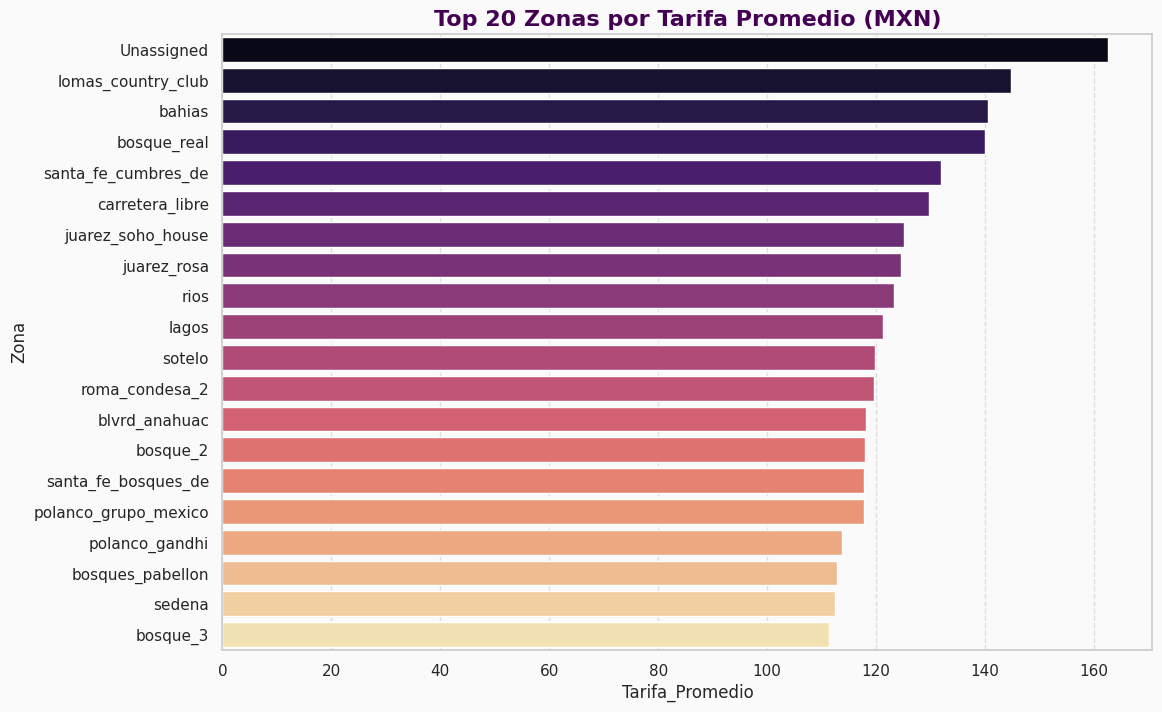

In [3]:
# ==============================================================================
# CELL 2: ANÁLISIS ECONÓMICO POR ZONA (UPFRONT FARE)
# ==============================================================================
display(Markdown("### 💰 **Análisis Económico: Tarifa Promedio por Zona**"))

try:
    # 1. CARGA DE TARIFAS (SSoT)
    query_fares = "SELECT offer_id, upfront_fare FROM offers"
    df_fares = pd.read_sql(query_fares, db_engine)
    df_fares.columns = df_fares.columns.str.lower()

    # 2. CARGA DE MAPEO (Generado en Cell 1)
    zones_csv_path = f"{DUMP_DIR}/{PREFIX}_final_zones.csv"
    df_zones = pd.read_csv(zones_csv_path)

    # 3. FUSIÓN Y CÁLCULO
    df_econ_geo = pd.merge(df_fares, df_zones, on='offer_id', how='inner')
    
    zone_economics = df_econ_geo.groupby('zone_name')['upfront_fare'].agg(['mean', 'count']).reset_index()
    zone_economics = zone_economics.rename(columns={
        'zone_name': 'Zona', 
        'mean': 'Tarifa_Promedio', 
        'count': 'Ofertas'
    }).sort_values('Tarifa_Promedio', ascending=False)

    # 4. REPORTE VISUAL
    display(zone_economics.style.background_gradient(cmap='Greens', subset=['Tarifa_Promedio']))

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=zone_economics.head(20),
        y='Zona', 
        x='Tarifa_Promedio',
        palette='magma'
    )
    plt.title(f'Top 20 Zonas por Tarifa Promedio (MXN)', fontsize=16, weight='bold', color=OPUS_PURPLE)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

except Exception as e:
    print(f"🔴 ERROR: {e}")

### ⚡️ **Análisis de Eficiencia: EPH Operacional por Zona**

#### **Ranking de Zonas por EPH Promedio (Solo UberX)**

,zone_name,avg_eph,n
38,lomas_olimpo,309.090909,1
71,vistahermosa,251.312823,7
70,vialidad_de_la_barranca,234.136498,32
11,bosque_2,232.396571,5
9,bondojito_asf,230.180029,10
26,interlomas_haciendas,229.920742,11
28,irrigacion,219.491144,9
42,nodo_monte_libano,218.071646,14
35,lomas_barrilaco,214.129691,10
64,sante_fe_patio,213.065564,65


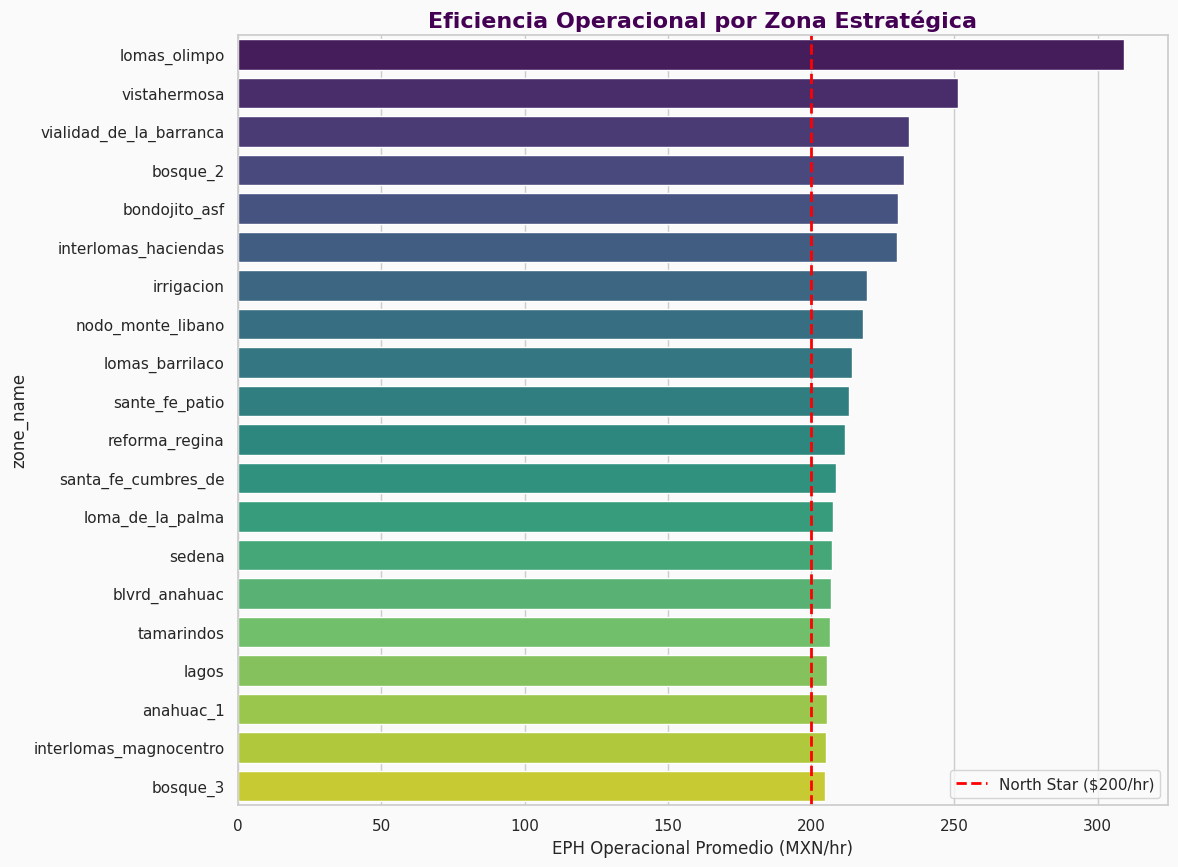

In [4]:
# ==============================================================================
# CELL 3: ANÁLISIS DE EFICIENCIA (EPH OP - UBERX - MONOLITO)
# ==============================================================================
display(Markdown("### ⚡️ **Análisis de Eficiencia: EPH Operacional por Zona**"))

try:
    # 1. CARGA DE PUNTOS Y EPH (Uniendo con engineered_features)
    query_efficiency = """
    SELECT 
        o.offer_id, o.product_category_fk,
        ef.eph_operational,
        pc.category_name
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
    """
    df_efficiency = pd.read_sql(query_efficiency, db_engine)
    df_efficiency.columns = df_efficiency.columns.str.lower()

    # 2. UNIR CON LAS ZONAS DE CELL 1
    df_analysis = pd.merge(df_efficiency, df_zones, on='offer_id', how='inner')

    # 3. FILTRADO POR UBERX (Core Business)
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)

    # 4. AGREGACIÓN
    zone_eff = df_uberx.groupby('zone_name')['eph_operational'].agg(['mean', 'count']).reset_index()
    zone_eff = zone_eff.rename(columns={'mean': 'avg_eph', 'count': 'n'}).sort_values('avg_eph', ascending=False)

    # 5. REPORTE Y VISUALIZACIÓN
    display(Markdown("#### **Ranking de Zonas por EPH Promedio (Solo UberX)**"))
    display(zone_eff.head(15))

    plt.figure(figsize=(12, 10))
    sns.barplot(data=zone_eff.head(20), y='zone_name', x='avg_eph', palette='viridis')
    
    # Baseline $200/hr
    plt.axvline(200, color='red', linestyle='--', linewidth=2, label='North Star ($200/hr)')
    
    plt.title('Eficiencia Operacional por Zona Estratégica', fontsize=16, weight='bold', color=OPUS_PURPLE)
    plt.xlabel('EPH Operacional Promedio (MXN/hr)')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"🔴 ERROR: {e}")

In [5]:
# ==============================================================================
# CELL: MAPA DE CALOR DE RENTABILIDAD DIVERGENTE (EPH OP - UBERX)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px
import numpy as np

display(Markdown("### 🗺️ **Mapa Divergente: EPH Operacional (UberX) vs. Baseline ($200)**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # 1. Cargar Puntos y Features
    query_points = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_points_raw = pd.read_sql(query_points, db_engine)
    df_points_raw.columns = df_points_raw.columns.str.lower()
    
    gdf_points = gpd.GeoDataFrame(
        df_points_raw,
        geometry=gpd.points_from_xy(df_points_raw.dropoff_lon, df_points_raw.dropoff_lat),
        crs="EPSG:4326"
    )

    # 2. Cargar Polígonos Canónicos
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    name_col = 'name' if 'name' in gdf_zonas.columns else 'Name'
    gdf_zonas = gdf_zonas.rename(columns={name_col: 'zone_name'})

    # 3. Cargar Categorías
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: ASIGNACIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas[['zone_name', 'geometry']], how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('Unassigned')
    
    df_analysis = pd.merge(
        pd.DataFrame(gdf_merged.drop(columns=['geometry', 'index_right'])),
        df_categories,
        left_on='product_category_fk',
        right_on='product_category_id',
        how='left'
    )
    
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print(f"✅ Datos de UberX asignados a zonas.")

    # --- FASE 3: CÁLCULO DE MÉTRICA ---
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)
    zone_efficiency = df_uberx.groupby('zone_name')['eph_operational'].mean().reset_index()

    # --- FASE 4: FUSIÓN FINAL ---
    gdf_map_data = pd.merge(gdf_zonas, zone_efficiency, on='zone_name', how='left')
    # Excluimos Unassigned del mapa para evitar huecos sin geometría
    gdf_map_data = gdf_map_data[gdf_map_data['zone_name'] != 'Unassigned']
    print("✅ Datos listos para visualización divergente.")

    # --- FASE 5: VISUALIZACIÓN DIVERGENTE (MODERN SYNTAX) ---
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    
    fig = px.choropleth_map(
        gdf_map_data,
        geojson=gdf_map_data.geometry,
        locations=gdf_map_data.index,
        color='eph_operational',
        map_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        opacity=0.8,
        height=850,
        title='Rentabilidad Geográfica: Desviación del Baseline ($200/hr)',
        hover_name='zone_name',
        
        # LA MAGIA DIVERGENTE: RdBu_r pone Rojo en lo Hot y Azul en lo Cold.
        # Al fijar el rango 150-250, el 200 queda en el color neutral (blanco/gris).
        color_continuous_scale="RdBu_r", 
        range_color=[150, 250],
        
        labels={'eph_operational': 'EPH Promedio'}
    )

    # Limpieza de Hover e Indicadores
    fig.update_traces(
        hovertemplate="<b>%{hovertext}</b><br><br>EPH Promedio: %{z:$.2f}/hr<extra></extra>"
    )

    fig.update_layout(
        margin={"r":0,"t":50,"l":0,"b":0},
        coloraxis_colorbar=dict(
            title="EPH (MXN/hr)",
            tickvals=[150, 175, 200, 225, 250],
            ticktext=["$150 (Frío)", "$175", "$200 (Baseline)", "$225", "$250+ (Hot)"]
        )
    )

    fig.show()

except Exception as e:
    print(f"🔴 ERROR EN MAPA DIVERGENTE: {e}")

### 🗺️ **Mapa Divergente: EPH Operacional (UberX) vs. Baseline ($200)**

✅ Activos cargados.
✅ Datos de UberX asignados a zonas.
✅ Datos listos para visualización divergente.


In [6]:
# ==============================================================================
# CELL: VALIDACIÓN GEOESPACIAL DE RECHAZOS (CON POLÍGONOS)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
import json

display(Markdown("### 🚦 **Validación Geoespacial de Rechazos (con Polígonos)**"))

# --- FASE 1: EXTRACCIÓN DE RECHAZOS ---
try:
    # Consultamos los rechazos que tienen una razón basada en geografía
    query_validation = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon,
        rp.reason_primary_description AS reason_primary
    FROM offers o
    LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
    WHERE
        o.dropoff_lat IS NOT NULL AND o.dropoff_lon IS NOT NULL
        AND rp.reason_primary_description IN ('dropoff_proxy', 'dropoff_non_operational')
    """
    df_validation = pd.read_sql(query_validation, db_engine)
    df_validation.columns = df_validation.columns.str.lower()
    print(f"✅ Se cargaron {len(df_validation)} rechazos geo-relevantes.")

    # --- FASE 2: CARGA DE POLÍGONOS (GEOJSON) ---
    if not os.path.exists(GEOJSON_PATH):
        raise FileNotFoundError(f"GeoJSON no encontrado en {GEOJSON_PATH}")
        
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    # Estandarización de nombre de columna (name/Name)
    name_col = 'name' if 'name' in gdf_zonas.columns else 'Name'
    gdf_zonas = gdf_zonas.rename(columns={name_col: 'zone_name'})
    print(f"✅ {len(gdf_zonas)} polígonos cargados para validación.")

    # --- FASE 3: VISUALIZACIÓN HÍBRIDA (SINTAXIS MODERNA) ---
    # En esta validación no usamos Jitter; queremos ver si el punto toca o no el borde
    df_validation['lat_viz'] = df_validation['dropoff_lat']
    df_validation['lon_viz'] = df_validation['dropoff_lon']

    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    
    fig = px.scatter_map(
        df_validation,
        lat="lat_viz",
        lon="lon_viz",
        color="reason_primary",
        map_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        height=850,
        title='Audit: ¿Están los rechazos fuera de las Zonas Seguras?',
        color_discrete_map={
            'dropoff_non_operational': 'firebrick', # Rojo: Veto
            'dropoff_proxy': 'goldenrod'            # Dorado: Proxy
        },
        hover_name='offer_id'
    )

    # --- FASE 4: SUPERPOSICIÓN DE POLÍGONOS ---
    # Convertimos el GeoDataFrame a un diccionario GeoJSON para Plotly
    with open(GEOJSON_PATH, 'r') as f:
        geojson_dict = json.load(f)

    fig.update_layout(
        margin={"r":0,"t":50,"l":0,"b":0},
        map_layers=[
            {
                "sourcetype": "geojson",
                "source": geojson_dict,
                "type": "line", # Dibujamos el perímetro para no tapar los puntos
                "color": "black",
                "line": {"width": 1.5}
            }
        ]
    )

    fig.show()

except FileNotFoundError as e:
    print(f"🔴 ERROR: {e}")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### 🚦 **Validación Geoespacial de Rechazos (con Polígonos)**

✅ Se cargaron 2602 rechazos geo-relevantes.
✅ 72 polígonos cargados para validación.


In [7]:
# ==============================================================================
# CELL: RENOMBRADO FINAL Y EXPORTACIÓN MAESTRA (Standardization)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import os

display(Markdown("### 🧹 **Standardization: Limpieza y Commit Final**"))

# 1. CARGAR DATOS (Desde el archivo generado en Cell 1)
INPUT_PATH = f"{DUMP_DIR}/{PREFIX}_final_zones.csv"
OUTPUT_PATH = f"{DUMP_DIR}/{PREFIX}_polygon_master.csv"

try:
    if not os.path.exists(INPUT_PATH):
        raise FileNotFoundError(f"No se encontró el archivo de zonas: {INPUT_PATH}. Ejecuta la Cell 1 primero.")
        
    df_final_master = pd.read_csv(INPUT_PATH)
    
    # 2. DEFINIR MÁSCARA DE LIMPIEZA
    # Buscamos cualquier vestigio de nombres viejos, nulos o IDs negativos
    nombres_sucios = ['EXTERIOR / VETO', 'unassigned', '-1', -1, 'NaN', 'None']
    mask_unassigned = df_final_master['zone_name'].isin(nombres_sucios) | df_final_master['zone_name'].isna()
    
    count_unassigned = mask_unassigned.sum()

    # 3. APLICAR CAMBIO (Capital "U" para estándar)
    if count_unassigned > 0:
        df_final_master.loc[mask_unassigned, 'zone_name'] = 'Unassigned'
        print(f"✅ Se estandarizaron {count_unassigned} registros al formato 'Unassigned'.")
    else:
        print("ℹ️ Todos los registros están limpios. No se requirió estandarización adicional.")

    # 4. RE-EXPORTAR (El artefacto definitivo)
    df_final_master.to_csv(OUTPUT_PATH, index=False)
    
    print("-" * 40)
    print(f"💾 COMMIT FINAL COMPLETADO.")
    print(f"📊 Total de ofertas mapeadas: {len(df_final_master)}")
    print(f"📂 Archivo Maestro guardado en: {OUTPUT_PATH}")

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🧹 **Standardization: Limpieza y Commit Final**

ℹ️ Todos los registros están limpios. No se requirió estandarización adicional.
----------------------------------------
💾 COMMIT FINAL COMPLETADO.
📊 Total de ofertas mapeadas: 4760
📂 Archivo Maestro guardado en: /workspaces/pienza/data/dumped_files/0406_polygon_master.csv


In [8]:
# ==============================================================================
# CELL: INSPECCIÓN FORENSE VISUAL (Detección de Solapamientos)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### 🕵️ **Inspección Forense: Auditoría de Duplicados por Solapamiento**"))

# 1. RECUPERAR DATOS DE ZONAS
INPUT_PATH = f"{DUMP_DIR}/{PREFIX}_polygon_master.csv"

try:
    if 'df_final_master' in locals():
        df_investigation = df_final_master.copy()
        print("✅ Analizando dataframe en memoria.")
    elif os.path.exists(INPUT_PATH):
        df_investigation = pd.read_csv(INPUT_PATH)
        print(f"✅ Cargando desde disco: {INPUT_PATH}")
    else:
        raise FileNotFoundError("No se encontraron datos de zonas. Ejecuta las celdas anteriores.")

    # 2. DETECTAR DUPLICADOS (Offers asignadas a >1 polígono)
    dupes_mask = df_investigation.duplicated(subset=['offer_id'], keep=False)
    df_dupes_raw = df_investigation[dupes_mask].copy()
    
    num_dupes_ids = df_dupes_raw['offer_id'].nunique()

    if num_dupes_ids == 0:
        display(Markdown("### ✅ **Todo limpio.** No hay conflictos de solapamiento geoespacial."))
    else:
        display(Markdown(f"### 🚨 **CONFLICTO DETECTADO: {num_dupes_ids} IDs duplicados**"))
        display(Markdown("Esto ocurre cuando un punto cae en dos polígonos a la vez. Cruzando con direcciones para resolución manual..."))

        # 3. ENRIQUECER CON DIRECCIONES (Contexto Humano)
        # Traemos las direcciones de la DB para poder decidir
        dupes_list = df_dupes_raw['offer_id'].unique().tolist()
        placeholders = ', '.join(['?'] * len(dupes_list))
        query_context = f"SELECT offer_id, dropoff_address FROM offers WHERE offer_id IN ({placeholders})"
        
        df_context = pd.read_sql(query_context, db_engine, params=dupes_list)
        df_context.columns = df_context.columns.str.lower()

        # Merge del conflicto con el contexto
        df_forense = pd.merge(df_dupes_raw, df_context, on='offer_id', how='left')

        # 4. VISUALIZACIÓN TÁCTICA
        cols_to_view = [
            'offer_id',
            'dropoff_address', # El contexto para decidir
            'zone_name'        # Los polígonos que se están "peleando" el punto
        ]
        
        display(df_forense[cols_to_view].sort_values('offer_id'))
        
        display(Markdown("""
        ---
        **Instrucciones de Resolución:**
        Si ves duplicados arriba, toma nota del `offer_id` y el `zone_name` que **NO** corresponde. 
        En la siguiente celda aplicaremos la 'Sentencia de Muerte' para limpiar el dataset.
        """))

except Exception as e:
    print(f"🔴 ERROR EN INSPECCIÓN: {e}")

### 🕵️ **Inspección Forense: Auditoría de Duplicados por Solapamiento**

✅ Analizando dataframe en memoria.


### ✅ **Todo limpio.** No hay conflictos de solapamiento geoespacial.

In [9]:
# ==============================================================================
# CELL: EJECUCIÓN DE SENTENCIA (Corrección Manual Definitiva)
# ==============================================================================
import pandas as pd
import os

# 1. RECUPERAR DATOS (Memoria o Disco)
INPUT_PATH = f"{DUMP_DIR}/{PREFIX}_polygon_master.csv"
OUTPUT_PATH = f"{DUMP_DIR}/{PREFIX}_polygon_master.csv" # Sobrescribimos con la versión limpia

try:
    if 'df_final_master' in locals():
        df_work = df_final_master.copy()
        print("✅ Usando datos en memoria (df_final_master).")
    elif os.path.exists(INPUT_PATH):
        df_work = pd.read_csv(INPUT_PATH)
        print(f"✅ Cargando datos desde disco: {INPUT_PATH}")
    else:
        raise FileNotFoundError("🔴 Error: No hay datos de zonas para corregir. Ejecuta las celdas anteriores.")

    # 2. TUS DECISIONES (Manual Fixes)
    manual_fixes = {
        'OF01459': 'lomas_fc_cuernavaca',  # Periférico lado Lomas
        'OF03579': 'lomas_fc_cuernavaca',  # Periférico lado Lomas (segundo caso)
        'OF03984': 'roma_condesa_1'        # Jojutla 6 es Condesa
    }

    print(f"🔧 Iniciando corrección manual para {len(manual_fixes)} conflictos...")

    # 3. APLICAR CORRECCIONES
    # Creamos una máscara: por defecto mantenemos todo
    keep_mask = pd.Series([True] * len(df_work), index=df_work.index)

    for oid, target_zone in manual_fixes.items():
        # Identificamos las filas de este ID específico
        id_rows = df_work['offer_id'] == oid

        # Marcamos como False (eliminar) las filas que NO coinciden con tu elección
        # Nota: Usamos 'zone_name' que es nuestro estándar actual
        bad_rows = id_rows & (df_work['zone_name'] != target_zone)

        if bad_rows.any():
            keep_mask[bad_rows] = False
            print(f"  ✅ ID {oid}: Se eliminó el conflicto, mantenemos '{target_zone}'.")
        else:
            print(f"  ⚠️ ID {oid}: No encontré conflictos para eliminar. ¿Ya estaba limpio?")

    # Aplicamos el filtro de limpieza
    df_final_master = df_work[keep_mask].copy()

    # 4. SEGURIDAD FINAL (Deduplicación técnica)
    # Garantizamos que cada offer_id sea único (Primary Key)
    dupes_remaining = df_final_master.duplicated(subset=['offer_id']).sum()
    if dupes_remaining > 0:
        print(f"🧹 Eliminando {dupes_remaining} duplicados residuales automáticos...")
        df_final_master = df_final_master.drop_duplicates(subset=['offer_id'], keep='first')

    # 5. GUARDADO FINAL
    df_final_master.to_csv(OUTPUT_PATH, index=False)

    print("-" * 40)
    print(f"💾 EXPORTACIÓN COMPLETADA.")
    print(f"📊 Total de ofertas únicas: {len(df_final_master)}")
    print(f"📂 Archivo Maestro actualizado: {OUTPUT_PATH}")

except Exception as e:
    print(f"🔴 ERROR EN EJECUCIÓN DE SENTENCIA: {e}")

✅ Usando datos en memoria (df_final_master).
🔧 Iniciando corrección manual para 3 conflictos...
  ⚠️ ID OF01459: No encontré conflictos para eliminar. ¿Ya estaba limpio?
  ⚠️ ID OF03579: No encontré conflictos para eliminar. ¿Ya estaba limpio?
  ⚠️ ID OF03984: No encontré conflictos para eliminar. ¿Ya estaba limpio?
----------------------------------------
💾 EXPORTACIÓN COMPLETADA.
📊 Total de ofertas únicas: 4760
📂 Archivo Maestro actualizado: /workspaces/pienza/data/dumped_files/0406_polygon_master.csv


In [10]:
'''# ==============================================================================
# CELL: EXPORTACIÓN PARA AUDITORÍA MASIVA DE POLÍGONOS
# ==============================================================================
from IPython.display import display, Markdown

# ASUNCIÓN: `gdf_merged` (el resultado del sjoin) existe en memoria.
# Para seguridad, lo reconstruiremos desde cero.

display(Markdown("### 📜 **Generando Ledger de Auditoría Geoespacial Masiva**"))

try:
    # --- 1. RECONSTRUCCIÓN COMPLETA DE DATOS ---
    # Cargar todos los puntos con sus datos de texto
    query_full = "SELECT offer_id, pickup_address, dropoff_address, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon FROM offers"
    df_export_raw = pd.read_sql(query_full, db_engine)
    gdf_points_export = gpd.GeoDataFrame(
        df_export_raw,
        geometry=gpd.points_from_xy(df_export_raw.dropoff_lon, df_export_raw.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar los polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'polygon_name'})
    gdf_zonas['polygon_id'] = gdf_zonas.index # Creamos un ID numérico simple

    print("✅ Activos cargados (Puntos y Polígonos).")

    # --- 2. FUSIÓN GEOESPACIAL ---
    gdf_export_merged = gpd.sjoin(gdf_points_export, gdf_zonas[['polygon_name', 'polygon_id', 'geometry']], how="left", predicate='within')
    gdf_export_merged.drop(columns=['geometry', 'index_right'], inplace=True)
    gdf_export_merged['polygon_name'] = gdf_export_merged['polygon_name'].fillna('EXTERIOR / VETO')
    gdf_export_merged['polygon_id'] = gdf_export_merged['polygon_id'].fillna(-1) # Asignamos -1 al Ruido
    print("✅ Fusión completada.")

    # --- 3. SELECCIÓN Y ORDENAMIENTO FINAL ---
    # Seleccionar y reordenar las columnas al formato exacto que pediste
    final_columns = [
        'offer_id',
        'pickup_address',
        'dropoff_address',
        'pickup_lat',
        'pickup_lon',
        'dropoff_lat',
        'dropoff_lon',
        'polygon_id',
        'polygon_name'
    ]
    df_audit_final = gdf_export_merged[final_columns].sort_values(['polygon_id', 'offer_id'])

    # --- 4. EXPORTACIÓN A GOOGLE DRIVE ---
    OUTPUT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_final.csv'
    df_audit_final.to_csv(OUTPUT_PATH, index=False)

    display(Markdown(f"✅ **¡Auditoría Exportada!** El archivo está listo en:"))
    display(Markdown(f"`{OUTPUT_PATH}`"))

except Exception as e:
    print(f"🔴 ERROR: {e}")'''

'# ==============================================================================\n# CELL: EXPORTACIÓN PARA AUDITORÍA MASIVA DE POLÍGONOS\n# ==============================================================================\nfrom IPython.display import display, Markdown\n\n# ASUNCIÓN: `gdf_merged` (el resultado del sjoin) existe en memoria.\n# Para seguridad, lo reconstruiremos desde cero.\n\ndisplay(Markdown("### 📜 **Generando Ledger de Auditoría Geoespacial Masiva**"))\n\ntry:\n    # --- 1. RECONSTRUCCIÓN COMPLETA DE DATOS ---\n    # Cargar todos los puntos con sus datos de texto\n    query_full = "SELECT offer_id, pickup_address, dropoff_address, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon FROM offers"\n    df_export_raw = pd.read_sql(query_full, db_engine)\n    gdf_points_export = gpd.GeoDataFrame(\n        df_export_raw,\n        geometry=gpd.points_from_xy(df_export_raw.dropoff_lon, df_export_raw.dropoff_lat),\n        crs="EPSG:4326"\n    )\n\n    # Cargar los polígonos\n    GE

In [11]:
# ==============================================================================
# CELL: LA FORJA DEL DICCIONARIO H3 (NATIVA V4.4+)
# ==============================================================================
import h3
import geopandas as gpd
from IPython.display import display, Markdown
import json
import os

display(Markdown("### ⬢ **Operación Teselado: Polígonos -> Hexágonos (Native H3 v4.4+)**"))

# --- 1. CONFIGURACIÓN ---
H3_RESOLUTION = 9 
dict_output_path = f"{DUMP_DIR}/{PREFIX}_h3_zone_dictionary.json"

# --- 2. CARGA DE POLÍGONOS ---
try:
    if not os.path.exists(GEOJSON_PATH):
        raise FileNotFoundError(f"No se encontró el GeoJSON en {GEOJSON_PATH}")

    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    name_col = 'name' if 'name' in gdf_zonas.columns else 'Name'
    gdf_zonas = gdf_zonas.rename(columns={name_col: 'zone_name'})
    
    print(f"✅ {len(gdf_zonas)} polígonos cargados.")
    print(f"ℹ️ Versión activa de H3: {h3.__version__}")

    # --- 3. EL "POLYFILL" (LA MAGIA DE V4) ---
    print(f"⏳ Realizando teselado con resolución H3={H3_RESOLUTION}...")

    hex_to_zone_map = {}

    for _, row in gdf_zonas.iterrows():
        zone = row['zone_name']
        geom = row.geometry

        try:
            # h3.geo_to_cells procesa nativamente geometrías de GeoPandas
            # (soporta Polygons, MultiPolygons y elevaciones Z automáticamente)
            hexagons = h3.geo_to_cells(geom, H3_RESOLUTION)
            
            for hex_id in hexagons:
                hex_to_zone_map[hex_id] = zone
                
        except Exception as poly_err:
            print(f"⚠️ Error procesando polígono '{zone}': {poly_err}")

    print("✅ ¡Teselado completado exitosamente!")

    # --- 4. REPORTE Y GUARDADO ---
    num_hexagons = len(hex_to_zone_map)
    display(Markdown(f"### 🗺️ **Diccionario Maestro H3 Creado**"))
    print(f"- Total de Hexágonos Únicos: {num_hexagons}")
    print(f"- Resolución: {H3_RESOLUTION}")

    with open(dict_output_path, 'w') as f:
        json.dump(hex_to_zone_map, f)

    display(Markdown(f"✅ **Diccionario guardado en:** `{dict_output_path}`"))

except Exception as e:
    print(f"🔴 ERROR EN TESELADO: {e}")

### ⬢ **Operación Teselado: Polígonos -> Hexágonos (Native H3 v4.4+)**

✅ 72 polígonos cargados.
ℹ️ Versión activa de H3: 4.4.2
⏳ Realizando teselado con resolución H3=9...
✅ ¡Teselado completado exitosamente!


### 🗺️ **Diccionario Maestro H3 Creado**

- Total de Hexágonos Únicos: 685
- Resolución: 9


✅ **Diccionario guardado en:** `/workspaces/pienza/data/dumped_files/0406_h3_zone_dictionary.json`

In [12]:
# ==============================================================================
# CELL: CRISTALIZACIÓN ESTRUCTURAL (JSON -> TABLA MAESTRA)
# ==============================================================================
import pandas as pd
from IPython.display import display, Markdown
import os

display(Markdown("### 💎 **Operación Cristal: Creando Tabla Maestra de Hexágonos**"))

try:
    # --- 1. VERIFICACIÓN DE PRE-REQUISITOS ---
    if 'hex_to_zone_map' not in locals():
        raise ValueError("El diccionario 'hex_to_zone_map' no está en memoria. Ejecuta la celda del teselado primero.")

    # --- 2. CONVERSIÓN DICT -> DATAFRAME ---
    print("⏳ Transmutando diccionario a estructura tabular...")
    df_h3_master = pd.DataFrame(list(hex_to_zone_map.items()), columns=['h3_index', 'zone_name'])

    # Añadimos la resolución como metadato, vital para no mezclar resoluciones en cruces futuros
    df_h3_master['resolution'] = H3_RESOLUTION

    # --- 3. VALIDACIÓN DE INTEGRIDAD ---
    total_rows = df_h3_master.shape[0]
    unique_hexes = df_h3_master['h3_index'].nunique()

    if total_rows == unique_hexes:
        print(f"✅ INTEGRIDAD PERFECTA: {total_rows} Hexágonos únicos confirmados.")
    else:
        print(f"⚠️ ALERTA: Se encontraron {total_rows - unique_hexes} duplicados. Aplicando deduplicación forzosa...")
        df_h3_master = df_h3_master.drop_duplicates(subset=['h3_index'], keep='first')

    # --- 4. EXPORTACIÓN ---
    csv_output_path = f"{DUMP_DIR}/{PREFIX}_master_h3_zones.csv"
    df_h3_master.to_csv(csv_output_path, index=False)

    display(Markdown(f"### 💾 **Artefacto Tabular Guardado**"))
    display(Markdown(f"`{csv_output_path}`\n\n*Este archivo es la tabla puente definitiva para **Opus**. Conectará cualquier coordenada GPS de la CDMX con su zona semántica en milisegundos.*"))

    # --- 5. VISTA PREVIA ---
    print("\n🔍 Muestra de la Matriz Hexagonal:")
    display(df_h3_master.head())

except Exception as e:
    print(f"🔴 ERROR EN CRISTALIZACIÓN: {e}")

### 💎 **Operación Cristal: Creando Tabla Maestra de Hexágonos**

⏳ Transmutando diccionario a estructura tabular...
✅ INTEGRIDAD PERFECTA: 685 Hexágonos únicos confirmados.


### 💾 **Artefacto Tabular Guardado**

`/workspaces/pienza/data/dumped_files/0406_master_h3_zones.csv`

*Este archivo es la tabla puente definitiva para **Opus**. Conectará cualquier coordenada GPS de la CDMX con su zona semántica en milisegundos.*


🔍 Muestra de la Matriz Hexagonal:


,h3_index,zone_name,resolution
0,894995bac43ffff,polanco_parque_lincoln,9
1,894995bae93ffff,polanco_parque_lincoln,9
2,894995bac5bffff,polanco_parque_lincoln,9
3,894995bae83ffff,polanco_parque_lincoln,9
4,894995bae97ffff,polanco_parque_lincoln,9


In [13]:
# ==============================================================================
# CELL: THE FUSION LINK (FULL UNIVERSE VERSION - NATIVE NULLS)
# ==============================================================================
# Objective: Generate H3 Links for EVERY offer, preserving row count integrity.
# ==============================================================================
import h3
import pandas as pd
import os
from IPython.display import display, Markdown

display(Markdown("### 🔗 **Operación Fusión: Mapeo del Universo Completo**"))

# --- 0. CONFIGURACIÓN ---
H3_RESOLUTION = 9
MASTER_ZONES_PATH = f"{DUMP_DIR}/{PREFIX}_master_h3_zones.csv"
OUTPUT_LINK_PATH = f"{DUMP_DIR}/{PREFIX}_h3_hex_id.csv"

try:
    # --- 1. EXTRACCIÓN (SIN FILTROS) ---
    print(f"📡 Consultando Opus.db...")

    query = """
    SELECT
        offer_id,
        dropoff_lat,
        dropoff_lon
    FROM offers
    """
    df_offers_geo = pd.read_sql(query, db_engine)
    current_count = len(df_offers_geo)
    print(f"✅ Cargados {current_count} registros totales (Universo Completo).")

    # --- 2. CÁLCULO H3 (BLINDADO) ---
    print(f"⬢ Calculando índices H3 (Res: {H3_RESOLUTION})...")

    def get_hex_safe(lat, lon, res):
        if pd.isna(lat) or pd.isna(lon):
            return None
        try:
            return h3.latlng_to_cell(lat, lon, res) 
        except Exception:
            return None

    df_offers_geo['dropoff_h3_hex_id'] = df_offers_geo.apply(
        lambda x: get_hex_safe(x['dropoff_lat'], x['dropoff_lon'], H3_RESOLUTION), axis=1
    )

    # --- 3. EL CRUCE (MERGE CLÁSICO) ---
    print("🔗 Cruzando con la Matriz de Polígonos...")

    if 'df_h3_master' not in locals():
        if os.path.exists(MASTER_ZONES_PATH):
            df_h3_master = pd.read_csv(MASTER_ZONES_PATH)
        else:
            raise FileNotFoundError(f"CRÍTICO: No se encontró {MASTER_ZONES_PATH}.")

    # LEFT JOIN: Lo que no cruce se quedará como NaN (Comportamiento Original)
    df_fused = df_offers_geo.merge(
        df_h3_master[['h3_index', 'zone_name']],
        left_on='dropoff_h3_hex_id',
        right_on='h3_index',
        how='left'
    )

    df_fused = df_fused.rename(columns={'zone_name': 'dropoff_polygon_name'})

    # --- 4. AUDITORÍA Y LIMPIEZA ---
    final_cols = ['offer_id', 'dropoff_h3_hex_id', 'dropoff_polygon_name']
    df_final_link = df_fused[final_cols]

    # Test de Integridad (Anti-Dilución)
    final_count = len(df_final_link)
    assert final_count == current_count, f"❌ ERROR DE DILUCIÓN DETECTADO: {current_count} vs {final_count}"

    # Métricas para consola (Buscando nulos nativos)
    unassigned_count = df_final_link['dropoff_polygon_name'].isna().sum()
    assigned_count = final_count - unassigned_count

    print("-" * 40)
    print(f"📊 Total Offers (Input):  {current_count}")
    print(f"📊 Total Rows (Output):   {final_count}")
    print(f"📍 Dentro de Zonas:       {assigned_count}")
    print(f"👻 Exterior (NaNs):       {unassigned_count}")
    print("-" * 40)

    display(df_final_link.head())

    # --- 5. EXPORTACIÓN ---
    df_final_link.to_csv(OUTPUT_LINK_PATH, index=False)
    display(Markdown(f"✅ **Artefacto 'Silver Layer' Generado exitosamente:** `{OUTPUT_LINK_PATH}`"))

except Exception as e:
    print(f"🔴 ERROR EN LA FUSIÓN: {e}")

### 🔗 **Operación Fusión: Mapeo del Universo Completo**

📡 Consultando Opus.db...
✅ Cargados 4765 registros totales (Universo Completo).
⬢ Calculando índices H3 (Res: 9)...
🔗 Cruzando con la Matriz de Polígonos...
----------------------------------------
📊 Total Offers (Input):  4765
📊 Total Rows (Output):   4765
📍 Dentro de Zonas:       2544
👻 Exterior (NaNs):       2221
----------------------------------------


,offer_id,dropoff_h3_hex_id,dropoff_polygon_name
0,OF01322,89499565c4fffff,NaN
1,OF01875,89499589c07ffff,NaN
2,OF00923,89499588287ffff,NaN
3,OF02333,894995124cfffff,NaN
4,OF03254,89499505677ffff,NaN


✅ **Artefacto 'Silver Layer' Generado exitosamente:** `/workspaces/pienza/data/dumped_files/0406_h3_hex_id.csv`

In [14]:
# ==============================================================================
# CELL: VISUALIZACIÓN NATIVA (KEPLER.GL H3 MAP - SOP 0406)
# ==============================================================================
import pandas as pd
import os
from keplergl import KeplerGl
from IPython.display import display, Markdown

display(Markdown("### 🏛️ **El Panteón Geoespacial: Visualizando H3 Nativo**"))

# --- 1. CARGAR LA TABLA MAESTRA ---
# Usamos el CSV que creamos en la celda de Cristalización
MASTER_ZONES_PATH = f"{DUMP_DIR}/{PREFIX}_master_h3_zones.csv"

# ¡EL FIX DEL SOP 0406!
HTML_OUTPUT_PATH = f"{DUMP_DIR}/{PREFIX}_kepler_h3_map.html"

try:
    if not os.path.exists(MASTER_ZONES_PATH):
        raise FileNotFoundError(f"No se encontró {MASTER_ZONES_PATH}. Ejecuta la Cristalización primero.")

    df_hex = pd.read_csv(MASTER_ZONES_PATH)
    print(f"✅ Matriz H3 cargada: {len(df_hex)} hexágonos listos para renderizar.")

    # Agregamos una columna dummy (por si quieres jugar con la altura 3D en Kepler)
    df_hex['elevation_value'] = 10 

    # --- 2. INVOCAR A KEPLER.GL ---
    # Centramos en CDMX con un zoom decente
    config_cdmx = {
        "version": "v1",
        "config": {
            "mapState": {
                "latitude": 19.4326,
                "longitude": -99.1332,
                "zoom": 10.5
            }
        }
    }
    
    map_1 = KeplerGl(height=750, config=config_cdmx)
    map_1.add_data(data=df_hex, name='Opus_H3_Zones')

    # --- 3. INSTRUCCIONES TÁCTICAS ---
    display(Markdown("""
    ### 🚀 **Instrucciones para la Magia en Kepler:**
    1. Abre el menú lateral (ícono de flecha arriba a la izquierda).
    2. Ve a **Layers** y añade una nueva capa.
    3. Selecciona **Basic -> H3**.
    4. En el campo `Hex Id`, selecciona la columna **`h3_index`**.
    5. Para ver tus zonas, ve a **Color -> Color Based On** y selecciona **`zone_name`**.
    """))

    # Renderizado en línea (puede fallar dependiendo del backend de Jupyter en VSCode)
    display(map_1)

    # --- 4. EL SALVAVIDAS (EXPORTACIÓN HTML) ---
    map_1.save_to_html(data={"Opus_H3_Zones": df_hex}, file_name=HTML_OUTPUT_PATH)
    display(Markdown(f"🚑 *¿No ves el mapa arriba? No te preocupes. Descarga o abre este archivo en tu navegador:* `{HTML_OUTPUT_PATH}`"))

except Exception as e:
    print(f"🔴 ERROR EN RENDERIZADO: {e}")

### 🏛️ **El Panteón Geoespacial: Visualizando H3 Nativo**

✅ Matriz H3 cargada: 685 hexágonos listos para renderizar.
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter



    ### 🚀 **Instrucciones para la Magia en Kepler:**
    1. Abre el menú lateral (ícono de flecha arriba a la izquierda).
    2. Ve a **Layers** y añade una nueva capa.
    3. Selecciona **Basic -> H3**.
    4. En el campo `Hex Id`, selecciona la columna **`h3_index`**.
    5. Para ver tus zonas, ve a **Color -> Color Based On** y selecciona **`zone_name`**.
    

KeplerGl(config={'version': 'v1', 'config': {'mapState': {'latitude': 19.4326, 'longitude': -99.1332, 'zoom': …

Map saved to /workspaces/pienza/data/dumped_files/0406_kepler_h3_map.html!


🚑 *¿No ves el mapa arriba? No te preocupes. Descarga o abre este archivo en tu navegador:* `/workspaces/pienza/data/dumped_files/0406_kepler_h3_map.html`

In [15]:
# ==============================================================================
# CELL: INYECCIÓN DE DATOS REALES (THE MONEY MAP - SOP 0406)
# ==============================================================================
import pandas as pd
import h3
import os
from keplergl import KeplerGl
from IPython.display import display, Markdown

display(Markdown("### 💸 **The Money Map: Inyección de Datos Financieros Reales**"))

# --- 0. CONFIGURACIÓN ---
H3_RES = 9 
HTML_OUTPUT_PATH = f"{DUMP_DIR}/{PREFIX}_kepler_money_map.html"

try:
    print("🔌 Extrayendo finanzas de Opus.db...")

    # --- 1. EXTRACCIÓN (Usando el db_engine global de tu entorno) ---
    query = """
    SELECT
        upfront_fare,
        dropoff_lat,
        dropoff_lon
    FROM offers
    WHERE upfront_fare IS NOT NULL
      AND dropoff_lat IS NOT NULL
      AND dropoff_lon IS NOT NULL
    """
    
    df_offers = pd.read_sql(query, db_engine)

    print(f"💰 Ofertas con tarifa válida: {len(df_offers)}")
    print(f"   - Tarifa Promedio Global: ${df_offers['upfront_fare'].mean():.2f}")

    # --- 2. GEO-HASHING (Lat/Lon -> H3) ---
    print("⬢ Mapeando coordenadas a la grilla H3...")

    # Función nativa de H3 v4 usando las columnas correctas
    df_offers['hex_id'] = df_offers.apply(
        lambda row: h3.latlng_to_cell(row['dropoff_lat'], row['dropoff_lon'], H3_RES),
        axis=1
    )

    # --- 3. AGREGACIÓN (La Alquimia de Datos) ---
    print("⚙️ Condensando métricas por hexágono...")
    df_grid_real = df_offers.groupby('hex_id').agg(
        avg_fare=('upfront_fare', 'mean'),
        max_fare=('upfront_fare', 'max'),
        total_offers=('upfront_fare', 'count')
    ).reset_index()

    df_grid_real['avg_fare'] = df_grid_real['avg_fare'].round(2)
    
    print(f"📊 Grid Financiero listo: {len(df_grid_real)} hexágonos activos (Revenue Centers).")

    # --- 4. VISUALIZACIÓN EN KEPLER ---
    # Centramos en la CDMX para no arrancar en altamar
    config_cdmx = {
        "version": "v1",
        "config": {
            "mapState": {"latitude": 19.4326, "longitude": -99.1747, "zoom": 10.5}
        }
    }
    
    mapa_dinero = KeplerGl(height=750, config=config_cdmx)
    mapa_dinero.add_data(data=df_grid_real, name='Opus_Real_Market')

    display(Markdown("""
    ### 🚀 **Instrucciones para el *Datagasm* 3D:**
    1. Abre el menú de capas (Layers) > `Opus_Real_Market`.
    2. En 'Basic', selecciona tipo de capa **H3** y asigna la columna `hex_id`.
    3. **COLOR:** Haz clic en los 3 puntitos > Color Based On > `avg_fare`.
       *(Recomendación: Usa una paleta térmica de Amarillo a Rojo oscuro).*
    4. **ALTURA (El Efecto Manhattan):** Activa el switch de 'Height'.
       - Height Based On > `total_offers` (para ver dónde hay más volumen) o `avg_fare` (para ver dónde hay más dinero).
       - Sube el 'Elevation Scale' para levantar los rascacielos financieros.
    """))

    display(mapa_dinero)

    # --- 5. EL SALVAVIDAS HTML ---
    mapa_dinero.save_to_html(data={"Opus_Real_Market": df_grid_real}, file_name=HTML_OUTPUT_PATH)
    display(Markdown(f"🚑 *Si el mapa no carga en línea, abre la versión HTML en tu navegador:* `{HTML_OUTPUT_PATH}`"))

except Exception as e:
    print(f"🔴 ERROR EN MONEY MAP: {e}")

### 💸 **The Money Map: Inyección de Datos Financieros Reales**

🔌 Extrayendo finanzas de Opus.db...
💰 Ofertas con tarifa válida: 4760
   - Tarifa Promedio Global: $131.11
⬢ Mapeando coordenadas a la grilla H3...
⚙️ Condensando métricas por hexágono...
📊 Grid Financiero listo: 1716 hexágonos activos (Revenue Centers).
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter



    ### 🚀 **Instrucciones para el *Datagasm* 3D:**
    1. Abre el menú de capas (Layers) > `Opus_Real_Market`.
    2. En 'Basic', selecciona tipo de capa **H3** y asigna la columna `hex_id`.
    3. **COLOR:** Haz clic en los 3 puntitos > Color Based On > `avg_fare`.
       *(Recomendación: Usa una paleta térmica de Amarillo a Rojo oscuro).*
    4. **ALTURA (El Efecto Manhattan):** Activa el switch de 'Height'.
       - Height Based On > `total_offers` (para ver dónde hay más volumen) o `avg_fare` (para ver dónde hay más dinero).
       - Sube el 'Elevation Scale' para levantar los rascacielos financieros.
    

KeplerGl(config={'version': 'v1', 'config': {'mapState': {'latitude': 19.4326, 'longitude': -99.1747, 'zoom': …

Map saved to /workspaces/pienza/data/dumped_files/0406_kepler_money_map.html!


🚑 *Si el mapa no carga en línea, abre la versión HTML en tu navegador:* `/workspaces/pienza/data/dumped_files/0406_kepler_money_map.html`